# 04 - Netflix-paper RBM training with CD-1

This notebook starts the first true training phase for the Netflix-style RBM on MovieLens.
The previous notebooks built the forward and reconstruction pipeline.
Here we learn weights and biases from data using Contrastive Divergence with one Gibbs step (CD-1).

## 1. Training objective and CD-1 overview

This is the first true training notebook in the Netflix-style pipeline.
Previous notebooks built the visible encoding, hidden activation, and reconstruction logic.
This notebook learns parameters from data using CD-1.

Training steps:
- Positive phase: from observed visible ratings to hidden probabilities.
- Negative phase: reconstruct visible ratings and recompute hidden probabilities.
- Update weights and biases using data-driven statistics minus reconstruction-driven statistics.

Visible units are rating-level indicators for each movie.
Hidden units are latent feature detectors.
Hidden probabilities use a sigmoid.
Visible probabilities use a softmax across rating levels.

Eq. (2) Hidden conditional distribution (from the paper)

$$
p(h_j = 1 \mid V) =
\sigma\left(
 b_j +
 \sum_{i=1}^{m}
 \sum_{k=1}^{K}
 v_i^k W_{ij}^k
\right)
$$

Eq. (1) Visible conditional distribution (from the paper)

$$
p(v_i^k = 1 \mid h) =
\frac{
\exp\left(b_i^k + \sum_{j=1}^{F} h_j W_{ij}^k\right)
}{
\sum_{l=1}^{K}
\exp\left(b_i^l + \sum_{j=1}^{F} h_j W_{ij}^l\right)
}
$$

CD-1 update intuition:

$$
\Delta \theta \propto \mathbb{E}_{data}[\cdot] - \mathbb{E}_{model}[\cdot]
$$

## 2. Imports and data loading

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def resolve_project_root() -> Path:
    root = Path.cwd().resolve()
    if root.name == "notebooks":
        root = root.parent
    return root


def load_ratings_table() -> tuple[pd.DataFrame, Path]:
    root = resolve_project_root()
    candidates = [
        root / "data" / "processed" / "train_ratings.csv",
        root / "data" / "processed" / "ratings.csv",
        root / "data" / "processed" / "rating.csv",
        root / "data" / "rating.csv",
        root / "data" / "ratings.csv",
    ]

    for path in candidates:
        if path.exists():
            df = pd.read_csv(path)
            if {"userId", "movieId", "rating"}.issubset(df.columns):
                return df[["userId", "movieId", "rating"]].copy(), path

    data_dir = root / "data"
    search_dirs = [data_dir / "processed", data_dir]
    for directory in search_dirs:
        if not directory.exists():
            continue
        for path in sorted(directory.glob("*.csv")):
            try:
                df = pd.read_csv(path)
            except Exception:
                continue
            if {"userId", "movieId", "rating"}.issubset(df.columns):
                return df[["userId", "movieId", "rating"]].copy(), path

    raise FileNotFoundError("No ratings table found with columns userId, movieId, rating.")


ratings_df, ratings_path = load_ratings_table()
print(f"Using ratings table: {ratings_path}")
print("Ratings shape:", ratings_df.shape)
ratings_df.head()

Using ratings table: /Users/yixuan/Boltzmann Machine in Movie Lens/rbm-recsys/data/processed/train_ratings.csv
Ratings shape: (16000210, 3)


,userId,movieId,rating
0,28507,1176,4.0
1,131160,1079,3.0
2,131160,47,5.0
3,131160,21,3.0
4,85252,45,3.0


## 3. Build visible representation and initialize parameters

Visible units represent observed ratings only.
Missing ratings are masked out and do not contribute to training updates.

In [2]:
rating_levels = [0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0]
K = len(rating_levels)
rating_to_index = {float(r): idx for idx, r in enumerate(rating_levels)}

# Use a manageable subset for training demonstrations
max_users = 1000
max_movies = 1000
min_ratings_per_user = 20

user_counts = ratings_df.groupby("userId").size().reset_index(name="count")
eligible_users = user_counts[user_counts["count"] >= min_ratings_per_user]
eligible_users = eligible_users.sort_values(["count", "userId"], ascending=[False, True])
selected_user_ids = eligible_users["userId"].head(max_users).tolist()

subset_df = ratings_df[ratings_df["userId"].isin(selected_user_ids)].copy()
movie_counts = subset_df.groupby("movieId").size().reset_index(name="count")
selected_movie_ids = movie_counts.sort_values("count", ascending=False)["movieId"].head(max_movies).tolist()

subset_df = subset_df[subset_df["movieId"].isin(selected_movie_ids)].copy()

user_id_to_index = {uid: idx for idx, uid in enumerate(sorted(subset_df["userId"].unique()))}
movie_id_to_index = {mid: idx for idx, mid in enumerate(sorted(selected_movie_ids))}

num_users = len(user_id_to_index)
num_movies = len(movie_id_to_index)

V = np.zeros((num_users, K, num_movies), dtype=np.float32)
mask = np.zeros((num_users, num_movies), dtype=np.float32)

for row in subset_df.itertuples(index=False):
    uid = row.userId
    mid = row.movieId
    rating = float(row.rating)
    if rating not in rating_to_index:
        continue
    u_idx = user_id_to_index[uid]
    m_idx = movie_id_to_index[mid]
    k_idx = rating_to_index[rating]
    V[u_idx, k_idx, m_idx] = 1.0
    mask[u_idx, m_idx] = 1.0

print("Users in training subset:", num_users)
print("Movies in training subset:", num_movies)
print("V shape:", V.shape)
print("Mask shape:", mask.shape)
print("Observed ratings count:", int(mask.sum()))

Users in training subset: 1000
Movies in training subset: 1000
V shape: (1000, 10, 1000)
Mask shape: (1000, 1000)
Observed ratings count: 630479


The model now transitions from illustrative parameters to learnable parameters.

In [3]:
F = 50  # hidden features
rng = np.random.default_rng(42)

W = rng.normal(loc=0.0, scale=0.01, size=(K, num_movies, F)).astype(np.float32)
b_v = np.zeros((K, num_movies), dtype=np.float32)
# Negative hidden bias to avoid early saturation
b_h = np.full((F,), -1.0, dtype=np.float32)

print("W shape:", W.shape)
print("b_v shape:", b_v.shape)
print("b_h shape:", b_h.shape)
print("b_h init mean:", float(b_h.mean()))

W shape: (10, 1000, 50)
b_v shape: (10, 1000)
b_h shape: (50,)
b_h init mean: -1.0


## 4. Helper functions and Contrastive Divergence, CD-1 training loop

In [4]:
def sigmoid(x: np.ndarray) -> np.ndarray:
    return 1.0 / (1.0 + np.exp(-x))


def softmax_over_k(x: np.ndarray) -> np.ndarray:
    # Softmax across rating levels for each movie
    x_max = x.max(axis=1, keepdims=True)
    exp_x = np.exp(x - x_max)
    return exp_x / exp_x.sum(axis=1, keepdims=True)


def hidden_probs_from_visible(V_batch: np.ndarray, W: np.ndarray, b_h: np.ndarray) -> np.ndarray:
    # V_batch: (B, K, M), W: (K, M, F) -> (B, F)
    activation = np.einsum("bkm,kmf->bf", V_batch, W) + b_h
    return sigmoid(activation)


def sample_hidden(h_probs: np.ndarray, rng: np.random.Generator) -> np.ndarray:
    # Sample binary hidden states from probabilities
    return rng.binomial(1, h_probs).astype(np.float32)


def visible_probs_from_hidden(h_batch: np.ndarray, W: np.ndarray, b_v: np.ndarray) -> np.ndarray:
    # h_batch: (B, F), W: (K, M, F), b_v: (K, M) -> (B, K, M)
    scores = np.einsum("bf,kmf->bkm", h_batch, W) + b_v[None, :, :]
    return softmax_over_k(scores)


def cd1_update(V_batch: np.ndarray, mask_batch: np.ndarray, W: np.ndarray, b_v: np.ndarray, b_h: np.ndarray, rng: np.random.Generator):
    # Positive phase: data-driven statistics from observed ratings only
    h_probs_pos = hidden_probs_from_visible(V_batch, W, b_h)
    h_states = sample_hidden(h_probs_pos, rng)

    # Negative phase: reconstruct visibles from sampled h
    v_probs_neg_full = visible_probs_from_hidden(h_states, W, b_v)
    # Mask missing ratings so they do not contribute
    v_probs_neg = v_probs_neg_full * mask_batch[:, None, :]
    h_probs_neg = hidden_probs_from_visible(v_probs_neg, W, b_h)

    # Apply mask to positive and negative visible blocks
    V_pos = V_batch * mask_batch[:, None, :]
    V_neg = v_probs_neg

    # Gradients from positive - negative statistics
    pos_stats = np.einsum("bkm,bf->kmf", V_pos, h_probs_pos)
    neg_stats = np.einsum("bkm,bf->kmf", V_neg, h_probs_neg)

    grad_W = pos_stats - neg_stats
    grad_b_v = (V_pos - V_neg).sum(axis=0)
    grad_b_h = (h_probs_pos - h_probs_neg).sum(axis=0)

    return grad_W, grad_b_v, grad_b_h, v_probs_neg, h_probs_pos

Negative phase choice:
- We use visible softmax probabilities directly for the negative phase (expectation-based).
- Missing ratings are masked so they do not contribute to gradients or loss.
- This keeps CD-1 stable and interpretable for this educational notebook.

The loss below is a training diagnostic only.
The main goal is to verify that the RBM learns from observed data via CD-1.

In [5]:
learning_rate = 0.005
weight_decay = 1e-4
max_update_norm = 5.0
epochs = 8
batch_size = 50

num_batches = int(np.ceil(num_users / batch_size))
loss_history = []
mean_hidden_history = []
frac_high_history = []
frac_low_history = []
weight_norm_history = []

for epoch in range(1, epochs + 1):
    # Shuffle users each epoch
    perm = rng.permutation(num_users)
    epoch_loss = 0.0
    epoch_hidden_mean = 0.0
    epoch_frac_high = 0.0
    epoch_frac_low = 0.0
    total_observed = 0.0

    for b in range(num_batches):
        # Mini-batch slice
        batch_idx = perm[b * batch_size : (b + 1) * batch_size]
        V_batch = V[batch_idx]
        mask_batch = mask[batch_idx]

        # One CD-1 update (expectation-based negative phase)
        grad_W, grad_b_v, grad_b_h, v_probs_neg, h_probs_pos = cd1_update(
            V_batch, mask_batch, W, b_v, b_h, rng
        )

        # Weight decay to reduce aggressiveness
        grad_W = grad_W - weight_decay * W

        # Parameter updates
        dW = learning_rate * grad_W / batch_idx.size
        db_v = learning_rate * grad_b_v / batch_idx.size
        db_h = learning_rate * grad_b_h / batch_idx.size

        # Optional update clipping for stability
        update_norm = np.linalg.norm(dW)
        if update_norm > max_update_norm:
            scale = max_update_norm / (update_norm + 1e-8)
            dW *= scale
            if epoch == 1 and b == 0:
                print("Update clipped: W update norm capped")

        W += dW
        b_v += db_v
        b_h += db_h

        if epoch == 1 and b == 0:
            print(
                "Initial update norms | W:", float(np.linalg.norm(dW)),
                "b_v:", float(np.linalg.norm(db_v)),
                "b_h:", float(np.linalg.norm(db_h))
            )

        # Reconstruction loss on observed ratings (masked cross-entropy)
        eps = 1e-9
        v_pred = np.clip(v_probs_neg, eps, 1.0)
        loss = -(V_batch * np.log(v_pred)).sum(axis=1)  # sum over K
        loss = (loss * mask_batch).sum()
        epoch_loss += loss
        total_observed += mask_batch.sum()

        # Track hidden activation diagnostics
        epoch_hidden_mean += h_probs_pos.mean()
        epoch_frac_high += (h_probs_pos > 0.9).mean()
        epoch_frac_low += (h_probs_pos < 0.1).mean()

    avg_loss = epoch_loss / max(total_observed, 1.0)
    avg_hidden = epoch_hidden_mean / num_batches
    avg_high = epoch_frac_high / num_batches
    avg_low = epoch_frac_low / num_batches
    weight_norm = float(np.linalg.norm(W))

    loss_history.append(avg_loss)
    mean_hidden_history.append(avg_hidden)
    frac_high_history.append(avg_high)
    frac_low_history.append(avg_low)
    weight_norm_history.append(weight_norm)

    print(
        f"Epoch {epoch:02d} | Recon loss: {avg_loss:.4f} | Mean hidden: {avg_hidden:.4f} | "
        f">0.9: {avg_high:.3f} | <0.1: {avg_low:.3f} | W norm: {weight_norm:.2f}"
    )

print("\nOld behavior: mean hidden prob quickly near 1.0")
print("New behavior: check mean/frac diagnostics above for balance")

Initial update norms | W: 0.06675217300653458 b_v: 0.034159060567617416 b_h: 0.000500933441799134
Epoch 01 | Recon loss: 2.2578 | Mean hidden: 0.4928 | >0.9: 0.034 | <0.1: 0.000 | W norm: 7.50
Epoch 02 | Recon loss: 2.0649 | Mean hidden: 0.9303 | >0.9: 0.782 | <0.1: 0.000 | W norm: 9.06
Epoch 03 | Recon loss: 1.9547 | Mean hidden: 0.9797 | >0.9: 0.955 | <0.1: 0.000 | W norm: 10.36
Epoch 04 | Recon loss: 1.9073 | Mean hidden: 0.9862 | >0.9: 0.972 | <0.1: 0.000 | W norm: 11.36
Epoch 05 | Recon loss: 1.8821 | Mean hidden: 0.9886 | >0.9: 0.976 | <0.1: 0.000 | W norm: 12.13
Epoch 06 | Recon loss: 1.8672 | Mean hidden: 0.9898 | >0.9: 0.978 | <0.1: 0.000 | W norm: 12.74
Epoch 07 | Recon loss: 1.8573 | Mean hidden: 0.9905 | >0.9: 0.980 | <0.1: 0.000 | W norm: 13.26
Epoch 08 | Recon loss: 1.8505 | Mean hidden: 0.9910 | >0.9: 0.980 | <0.1: 0.000 | W norm: 13.70

Old behavior: mean hidden prob quickly near 1.0
New behavior: check mean/frac diagnostics above for balance


## 5. Training behavior and learned inspection

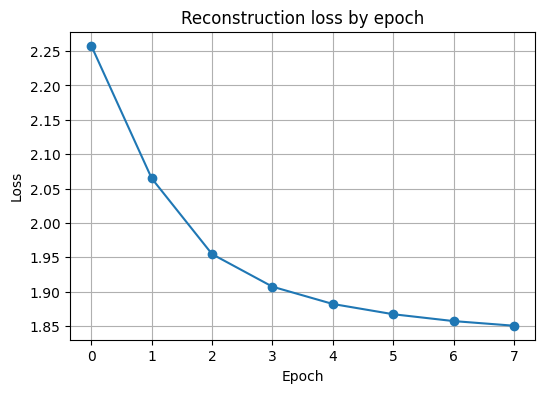

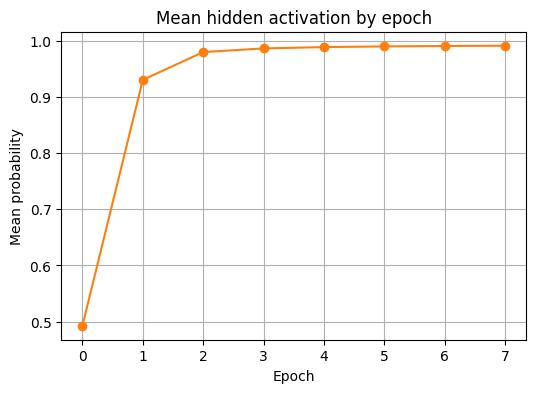

In [6]:
plt.figure(figsize=(6, 4))
plt.plot(loss_history, marker="o")
plt.title("Reconstruction loss by epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(mean_hidden_history, marker="o", color="tab:orange")
plt.title("Mean hidden activation by epoch")
plt.xlabel("Epoch")
plt.ylabel("Mean probability")
plt.grid(True)
plt.show()

Interpretation:
- If the mean hidden probability stays away from 1.0 and the >0.9 fraction is modest, saturation is reduced.
- A gentle downward trend in reconstruction loss indicates learning without runaway activation.
- If saturation remains high, reduce learning rate or increase negative bias further.

The loss is a diagnostic on observed ratings only. A downward trend suggests the RBM is learning from data.

Inspect learned results for a few users.

In [7]:
from IPython.display import display


def reconstruct_visible_from_probs(h_probs: np.ndarray, W: np.ndarray, b_v: np.ndarray) -> np.ndarray:
    scores = np.einsum("f,kmf->km", h_probs, W) + b_v
    return softmax_over_k(scores)


example_users = list(user_id_to_index.keys())[:2]

for uid in example_users:
    u_idx = user_id_to_index[uid]
    V_u = V[u_idx]
    mask_u = mask[u_idx]

    h_probs_u = hidden_probs_from_visible(V_u[None, :, :], W, b_h)[0]
    P_u = reconstruct_visible_from_probs(h_probs_u, W, b_v)

    print(f"\nUser {uid}")
    print("Hidden probabilities (first 10):", h_probs_u[:10])

    observed_movie_indices = np.where(mask_u > 0)[0][:5]
    for m_idx in observed_movie_indices:
        movie_id = list(movie_id_to_index.keys())[m_idx]
        observed_rating = rating_levels[int(V_u[:, m_idx].argmax())]
        probs = P_u[:, m_idx]
        df = pd.DataFrame(
            {
                "rating_level": rating_levels,
                "probability": probs,
            }
        )
        expected_rating = (np.array(rating_levels) * probs).sum()
        print(f"Movie {movie_id} | observed rating: {observed_rating} | predicted: {expected_rating:.3f}")
        display(df)


User 116
Hidden probabilities (first 10): [0.9640755  0.9736655  0.9723237  0.9740505  0.97075224 0.97065204
 0.9593244  0.96053314 0.9756796  0.9711873 ]
Movie 1 | observed rating: 3.0 | predicted: 0.038


,rating_level,probability
0,0.5,0.000793
1,1.0,0.000577
2,1.5,0.000673
3,2.0,0.000458
4,2.5,0.000657
5,3.0,0.000812
6,3.5,0.000914
7,4.0,0.001598
8,4.5,0.001475
9,5.0,0.002947


Movie 2 | observed rating: 2.0 | predicted: 0.024


,rating_level,probability
0,0.5,0.000840
1,1.0,0.000947
2,1.5,0.001268
3,2.0,0.001883
4,2.5,0.001646
5,3.0,0.001470
6,3.5,0.000908
7,4.0,0.000595
8,4.5,0.000414
9,5.0,0.000289


Movie 3 | observed rating: 2.0 | predicted: 0.023


...

,rating_level,probability
0,0.5,0.001142
1,1.0,0.001643
2,1.5,0.001269
3,2.0,0.001955
4,2.5,0.001430
5,3.0,0.001150
6,3.5,0.000563
7,4.0,0.000423
8,4.5,0.000522
9,5.0,0.000270


Movie 5 | observed rating: 3.0 | predicted: 0.022


,rating_level,probability
0,0.5,0.001463
1,1.0,0.001593
2,1.5,0.001802
3,2.0,0.001871
4,2.5,0.001687
5,3.0,0.001013
6,3.5,0.000595
7,4.0,0.000248
8,4.5,0.000448
9,5.0,0.000267


Movie 6 | observed rating: 4.0 | predicted: 0.030


,rating_level,probability
0,0.5,0.000765
1,1.0,0.000628
2,1.5,0.000706
3,2.0,0.000499
4,2.5,0.000656
5,3.0,0.000843
6,3.5,0.000996
7,4.0,0.001210
8,4.5,0.001434
9,5.0,0.001541


## 6. Summary

Previous notebooks built the inference pipeline.
This notebook completed the first real RBM training step with CD-1.
The model now learns weights from MovieLens data.
The natural next step is evaluation on held-out ratings by computing RMSE on a test split.